# Risk Factor Prediction of Chronic Kidney Disease

**Group:** 15  
**Dataset:** UCI Machine Learning Repository, Risk Factor Prediction of Chronic Kidney Disease  
**Main goal:** build an end-to-end AI4Medicine analytics pipeline that predicts CKD risk and extracts clinically useful risk-factor insights.

This notebook is organised to match the assignment rubric:

1. Problem definition and clinical relevance
2. Data understanding and preprocessing
3. Multiple justified analytics methods
4. Model validation and interpretation
5. Healthcare/business intelligence insights
6. Report-ready visualisations and conclusions

## 1. Problem Definition and Relevance

Chronic kidney disease (CKD) is a progressive loss of kidney function. Early risk identification is clinically valuable because timely screening, lifestyle advice, blood-pressure control, diabetes management, and nephrology referral can slow progression and reduce dialysis burden.

**Problem statement:** Given patient risk factors and laboratory indicators, develop an AI-based decision-support workflow that identifies patients likely to have CKD and highlights the strongest risk factors.

**Objectives**

- Predict whether a patient is CKD or non-CKD using classification models.
- Predict estimated kidney-function severity using regression on the GFR interval midpoint.
- Discover patient subgroups using unsupervised clustering.
- Mine association rules that connect clinical factors with CKD and advanced-stage CKD.
- Convert model outputs into actionable healthcare intelligence, such as screening priority and referral support.

**Clinical decision context**

The model is not a replacement for clinical diagnosis. It is framed as a screening and prioritisation aid for clinicians or healthcare administrators.

In [220]:
from pathlib import Path
import itertools
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    precision_recall_curve,
    r2_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

TABLE_DIR = Path("report_tables")
TABLE_DIR.mkdir(exist_ok=True)

for folder, pattern in [(TABLE_DIR, "*.csv")]:
    for old_file in folder.glob(pattern):
        old_file.unlink()

def save_table(df_to_save, filename):
    path = TABLE_DIR / filename
    df_to_save.to_csv(path, index=False)
    print(f"Saved table: {path}")


print("Most charts and tables are displayed inline only.")
print("Only final report-ready outputs are saved to report_figures/ and report_tables/.")

Most charts and tables are displayed inline only.
Only final report-ready outputs are saved to report_figures/ and report_tables/.


## 2. Data Source

The dataset was donated to the UCI Machine Learning Repository on 14 August 2023. UCI lists it as a multivariate Health and Medicine dataset with 200 instances and 28 features, associated with classification and regression tasks. The source page states that the data are real Bangladeshi patient data collected from Enam Medical College, Savar, Dhaka, Bangladesh.

**Citation:** Islam, M. & Akter, S. (2020). *Risk Factor Prediction of Chronic Kidney Disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5WP64

In [221]:
DATA_PATH = Path("ckd-dataset-v2.csv")
if not DATA_PATH.exists():
    # Fallback for running this notebook directly from the original assignment folder.
    DATA_PATH = Path(r"C:\Users\Ke Xin\Desktop\Master\KQC7016 Data Analytics\Assignment 2\risk+factor+prediction+of+chronic+kidney+disease\ckd-dataset-v2.csv")

raw = pd.read_csv(DATA_PATH, encoding="utf-8")
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (202, 29)


,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
0,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,...,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class,meta
2,0,0,1.019 - 1.021,1 - 1,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,≥ 227.944,s1,1,< 12
3,0,0,1.009 - 1.011,< 0,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,≥ 227.944,s1,1,< 12
4,0,0,1.009 - 1.011,≥ 4,ckd,1,< 0,1,0,1,...,0,0,0,1,0,0,127.281 - 152.446,s1,1,< 12


The CSV contains two metadata rows after the header:

- Row 1 marks all fields as discrete.
- Row 2 marks `class` and `meta` roles.

The actual patient records start after these two rows, so they are removed during preprocessing.

In [222]:
def clean_text_value(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    replacements = {
        "â‰¥": ">=",
        "â‰¤": "<=",
        "â\x89¥": ">=",
        "â\x89¤": "<=",
        "≤": "<=",
        "≥": ">=",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = text.replace(chr(8805), ">=").replace(chr(8804), "<=")
    text = text.replace("\u2265", ">=").replace("\u2264", "<=")
    return text


df = raw.iloc[2:].copy().reset_index(drop=True)
df = df.apply(lambda col: col.map(clean_text_value))

print("Patient record shape:", df.shape)
display(df.head())
display(df.describe(include="all").T[["count", "unique", "top", "freq"]].head(15))

Patient record shape: (200, 29)


,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
0,0,0,1.019 - 1.021,1 - 1,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,>= 227.944,s1,1,< 12
1,0,0,1.009 - 1.011,< 0,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,>= 227.944,s1,1,< 12
2,0,0,1.009 - 1.011,>= 4,ckd,1,< 0,1,0,1,...,0,0,0,1,0,0,127.281 - 152.446,s1,1,< 12
3,1,1,1.009 - 1.011,3 - 3,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,127.281 - 152.446,s1,1,< 12
4,0,0,1.015 - 1.017,< 0,ckd,0,< 0,0,0,0,...,0,1,0,1,1,0,127.281 - 152.446,s1,1,12 - 20


,count,unique,top,freq
bp (Diastolic),200,2,1,108
bp limit,200,3,0,95
sg,200,5,1.019 - 1.021,75
al,200,5,< 0,116
class,200,2,ckd,128
rbc,200,2,0,175
su,200,6,< 0,170
pc,200,2,0,155
pcc,200,2,0,173
ba,200,2,0,189


Missing values per column:


,missing_count
bp (Diastolic),0
hemo,0
affected,0
stage,0
grf,0
ane,0
pe,0
appet,0
cad,0
dm,0


Duplicate rows: 0

Target distribution:


,count
ckd,128
notckd,72



Stage distribution:


,count
s1,54
s2,35
s3,31
s4,45
s5,35


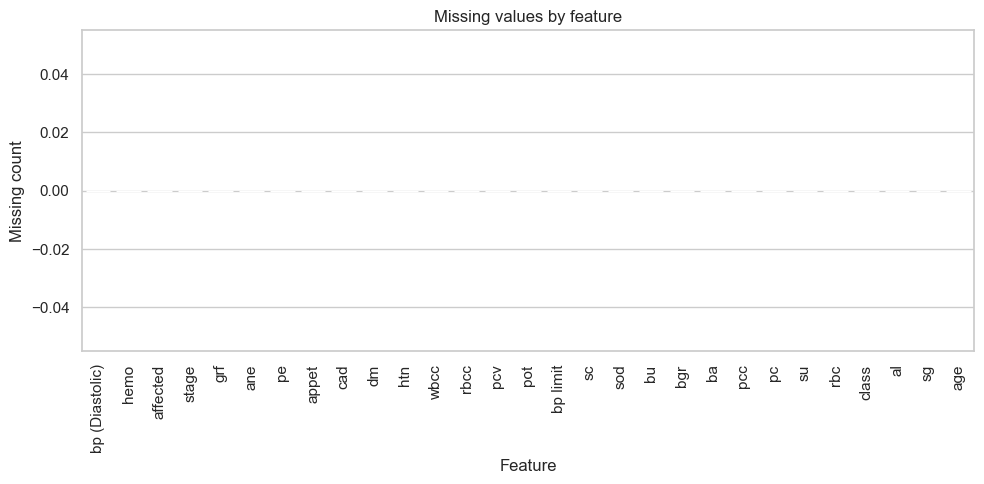

In [223]:
print("Missing values per column:")
missing_summary = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
display(missing_summary)

duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Shape after dropping duplicates:", df.shape)

print("\nTarget distribution:")
class_distribution = df["class"].value_counts().to_frame("count")
display(class_distribution)

print("\nStage distribution:")
stage_distribution = df["stage"].value_counts().sort_index().to_frame("count")
display(stage_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_summary.reset_index(), x="index", y="missing_count", color="#4C78A8")
plt.title("Missing values by feature")
plt.xlabel("Feature")
plt.ylabel("Missing count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Many fields are interval-coded strings such as `112 - 154`, `< 48.1`, or `>= 227.944`. For predictive modelling, these are handled as categorical values through one-hot encoding. For EDA and regression, interval midpoints are also derived to support visualisation and numerical target modelling.

Potential leakage is handled carefully. `grf`, `stage`, and `affected` are kidney outcome labels closely related to CKD status, so they are excluded from the CKD classifier input features.

In [224]:
def interval_midpoint(value):
    if pd.isna(value):
        return np.nan
    text = clean_text_value(value)
    nums = [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?", text)]
    if not nums:
        return np.nan
    if "-" in text and len(nums) >= 2:
        return float(np.mean(nums[:2]))
    return nums[0]


interval_columns = ["sg", "al", "su", "bgr", "bu", "sod", "sc", "pot", "hemo", "pcv", "rbcc", "wbcc", "grf", "age"]
numeric_mid = pd.DataFrame({f"{col}_mid": df[col].map(interval_midpoint) for col in interval_columns})

model_df = pd.concat([df, numeric_mid], axis=1)
model_df["ckd_binary"] = (model_df["class"].str.lower() == "ckd").astype(int)
model_df["advanced_stage"] = model_df["stage"].isin(["s4", "s5"]).astype(int)

display(model_df[["class", "ckd_binary", "stage", "advanced_stage", "grf", "grf_mid", "age", "age_mid"]].head())

,class,ckd_binary,stage,advanced_stage,grf,grf_mid,age,age_mid
0,ckd,1,s1,0,>= 227.944,227.9440,< 12,12.0
1,ckd,1,s1,0,>= 227.944,227.9440,< 12,12.0
2,ckd,1,s1,0,127.281 - 152.446,139.8635,< 12,12.0
3,ckd,1,s1,0,127.281 - 152.446,139.8635,< 12,12.0
4,ckd,1,s1,0,127.281 - 152.446,139.8635,12 - 20,16.0


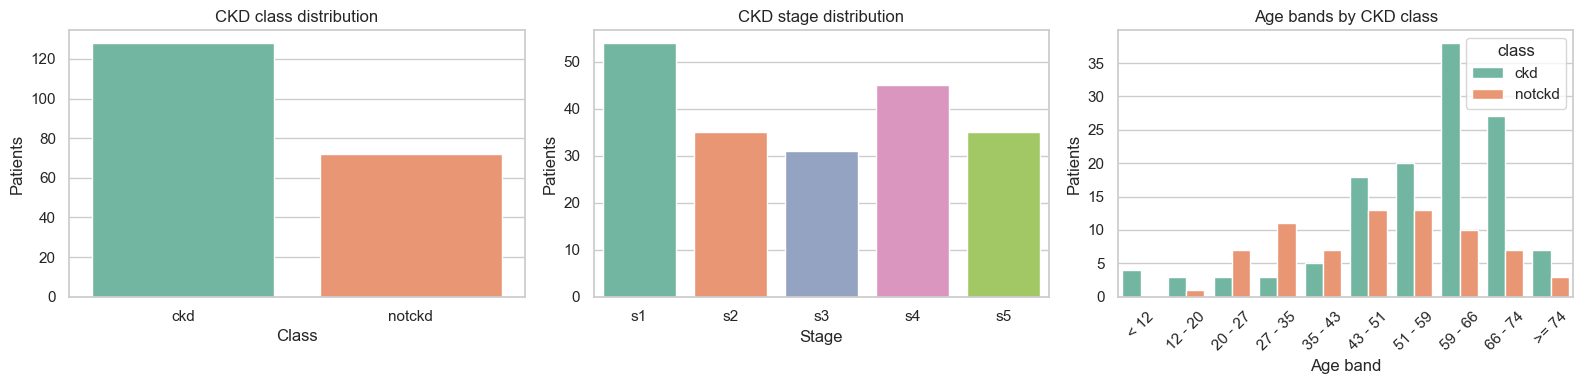

In [225]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=model_df, x="class", ax=axes[0])
axes[0].set_title("CKD class distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Patients")

sns.countplot(data=model_df, x="stage", order=sorted(model_df["stage"].unique()), ax=axes[1])
axes[1].set_title("CKD stage distribution")
axes[1].set_xlabel("Stage")
axes[1].set_ylabel("Patients")

sns.countplot(data=model_df, x="age", hue="class", ax=axes[2])
axes[2].set_title("Age bands by CKD class")
axes[2].set_xlabel("Age band")
axes[2].set_ylabel("Patients")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

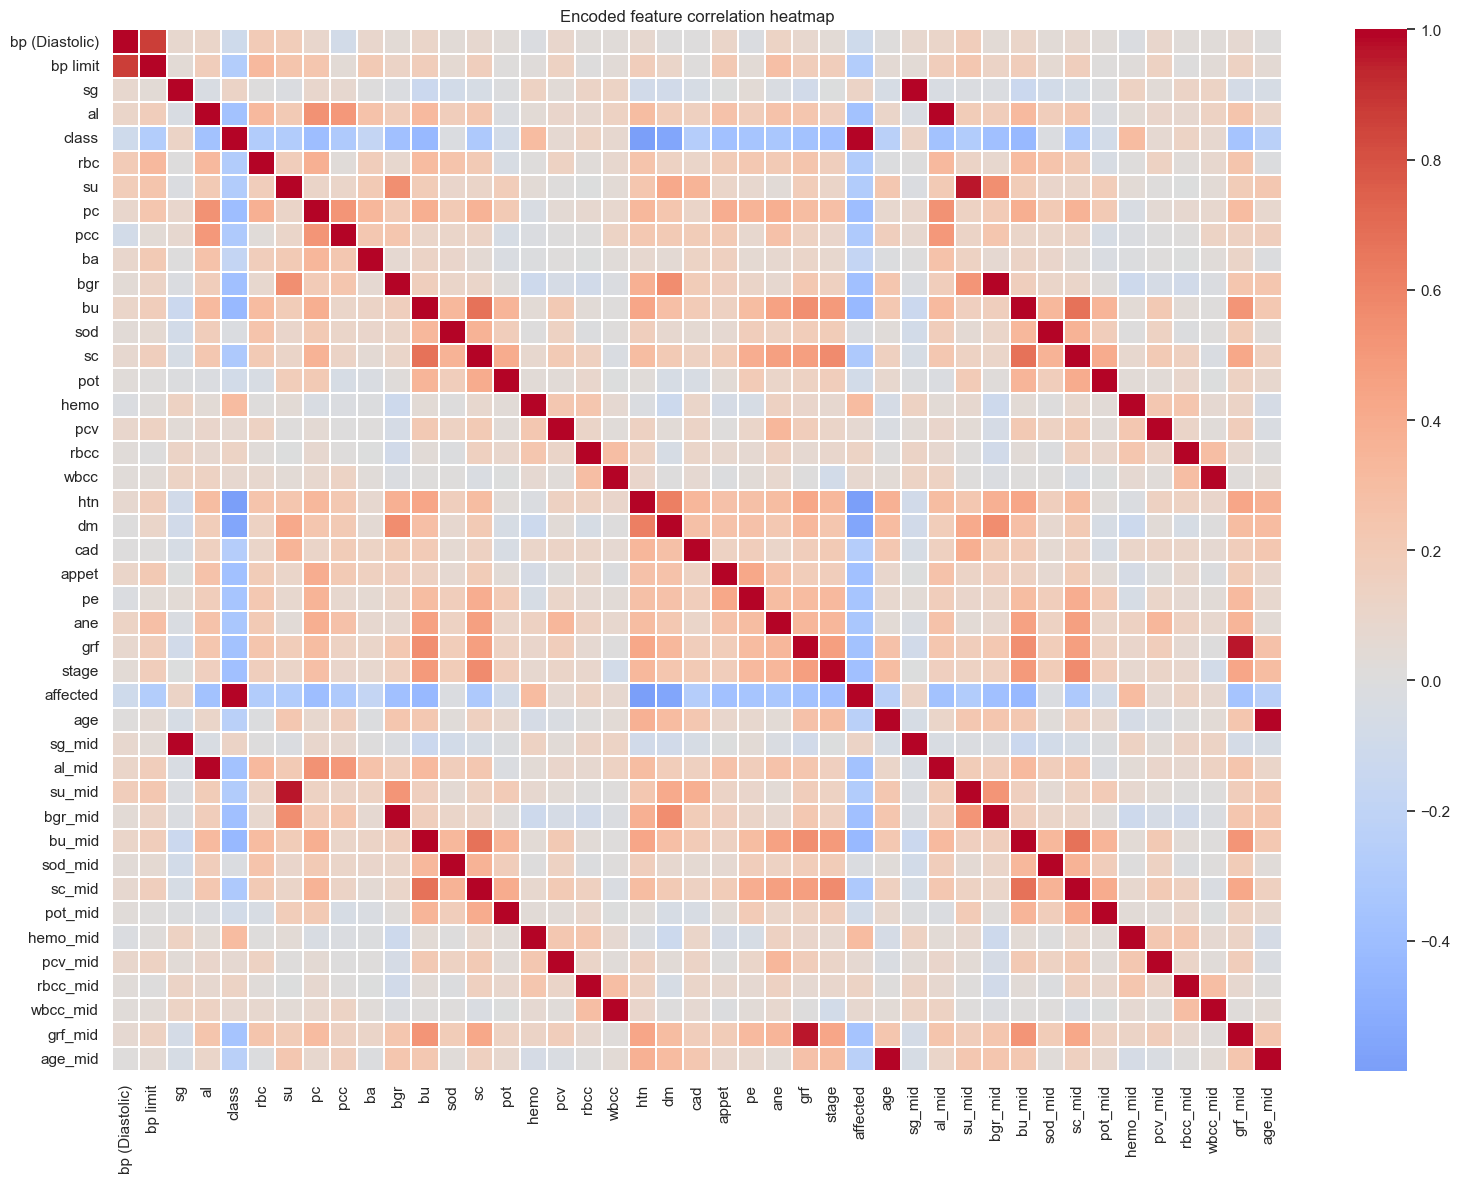

In [226]:
# Encoded correlation heatmap for report EDA.
# This is not used as the final model input; it is a visual data-understanding aid.
encoded_for_corr = model_df.drop(columns=["ckd_binary", "advanced_stage"]).copy()
for col in encoded_for_corr.columns:
    encoded_for_corr[col] = pd.factorize(encoded_for_corr[col])[0]

plt.figure(figsize=(16, 12))
sns.heatmap(encoded_for_corr.corr(numeric_only=True), cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Encoded feature correlation heatmap")
plt.tight_layout()
plt.show()

,feature,level,ckd_rate_percent
11,htn,1,100.000000
7,pcc,1,100.000000
19,pe,1,100.000000
17,appet,1,100.000000
15,cad,1,100.000000
13,dm,1,100.000000
9,ba,1,100.000000
21,ane,1,100.000000
5,pc,1,100.000000
3,rbc,1,100.000000


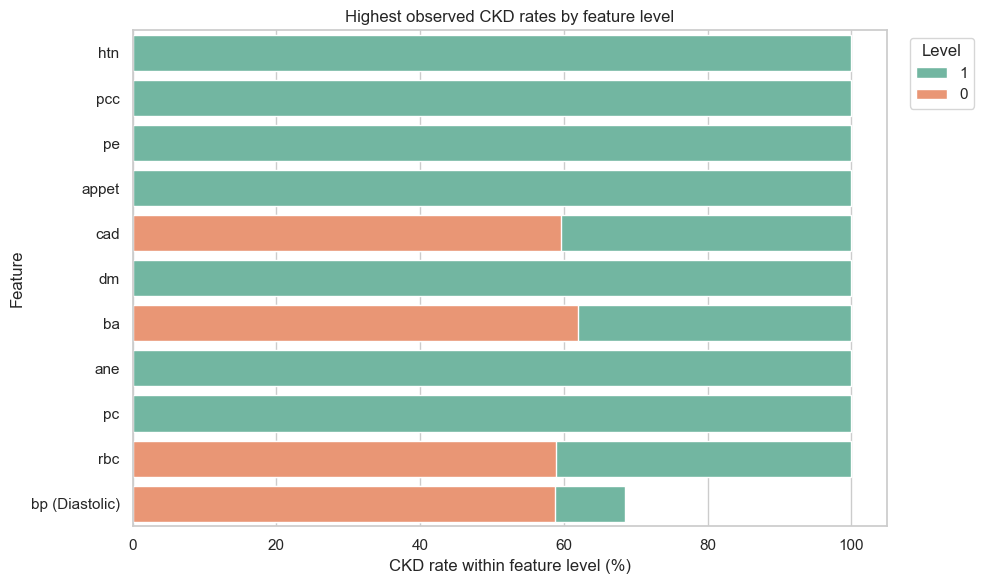

In [227]:
binary_risk_cols = ["bp (Diastolic)", "rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]

risk_summary = []
for col in binary_risk_cols:
    table = pd.crosstab(model_df[col], model_df["class"], normalize="index") * 100
    if "ckd" in table.columns:
        for level in table.index:
            risk_summary.append({"feature": col, "level": level, "ckd_rate_percent": table.loc[level, "ckd"]})

risk_summary = pd.DataFrame(risk_summary).sort_values("ckd_rate_percent", ascending=False)
display(risk_summary.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=risk_summary.head(15), y="feature", x="ckd_rate_percent", hue="level", dodge=False)
plt.title("Highest observed CKD rates by feature level")
plt.xlabel("CKD rate within feature level (%)")
plt.ylabel("Feature")
plt.legend(title="Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Method 1: CKD Classification

Classification is the core predictive method because the clinical task is to distinguish CKD from non-CKD patients. Multiple models are compared so that the final recommendation is evidence-based rather than model-specific.

**Models compared**

- Dummy baseline: confirms that the AI model beats a naive majority-class rule.
- Logistic regression: interpretable linear benchmark.
- Random forest: non-linear model with feature importance.
- Gradient boosting: strong tabular-data model.
- SVM and KNN: additional algorithm families for comparison.

Categorical features: 25
Numeric midpoint features: 13


,excluded_column,reason
0,class,Target label
1,ckd_binary,Engineered target label
2,grf,Kidney-function outcome measure
3,grf_mid,Numeric version of kidney-function outcome
4,stage,CKD severity outcome
5,advanced_stage,Engineered severity outcome
6,affected,Outcome-related affected label


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Random forest,0.995,0.010,0.992,0.015,1.000,0.000,0.996,0.008,1.000,0.000
4,SVM,0.990,0.012,1.000,0.000,0.985,0.019,0.992,0.010,1.000,0.000
1,Logistic regression,0.985,0.012,0.993,0.015,0.985,0.019,0.988,0.009,1.000,0.000
3,Gradient boosting,0.965,0.025,0.977,0.030,0.969,0.029,0.973,0.020,0.978,0.028
5,KNN,0.965,0.030,1.000,0.000,0.946,0.046,0.971,0.024,0.999,0.002
0,Dummy baseline,0.640,0.012,0.640,0.012,1.000,0.000,0.780,0.009,0.500,0.000


Saved table: report_tables\classification_cross_validation_results.csv


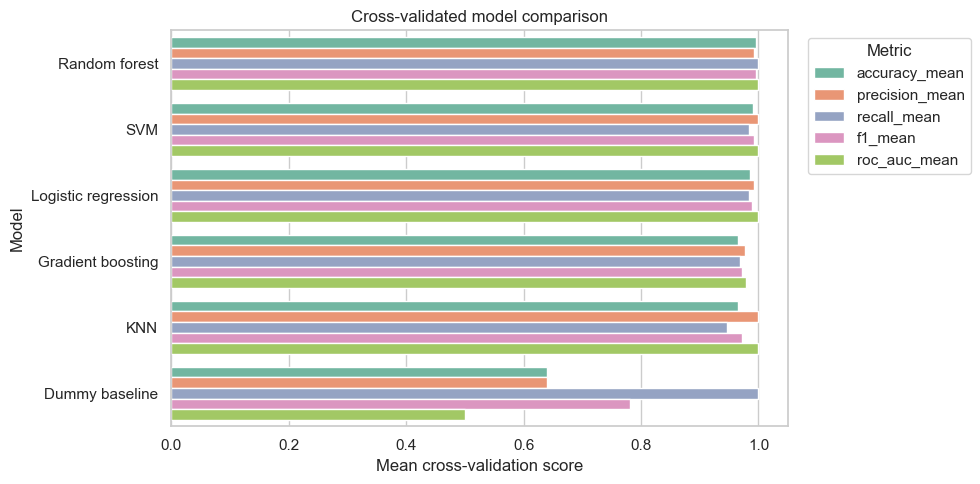

In [228]:
leakage_cols = ["class", "ckd_binary", "grf", "grf_mid", "stage", "advanced_stage", "affected"]
X = model_df.drop(columns=leakage_cols)
y = model_df["ckd_binary"]

numeric_features = [col for col in X.columns if col.endswith("_mid")]
categorical_features = [col for col in X.columns if col not in numeric_features]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot),
        ]), categorical_features),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ],
    remainder="drop",
)

print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric midpoint features: {len(numeric_features)}")

leakage_audit = pd.DataFrame({
    "excluded_column": leakage_cols,
    "reason": [
        "Target label",
        "Engineered target label",
        "Kidney-function outcome measure",
        "Numeric version of kidney-function outcome",
        "CKD severity outcome",
        "Engineered severity outcome",
        "Outcome-related affected label",
    ],
})
display(leakage_audit)

models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, estimator in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", estimator)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
display(cv_results.style.format({col: "{:.3f}" for col in cv_results.columns if col != "model"}))
save_table(cv_results, "classification_cross_validation_results.csv")

plt.figure(figsize=(10, 5))
plot_cv = cv_results.melt(
    id_vars="model",
    value_vars=["accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_cv, x="score", y="model", hue="metric")
plt.title("Cross-validated model comparison")
plt.xlabel("Mean cross-validation score")
plt.ylabel("Model")
plt.xlim(0, 1.05)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Best model by cross-validated F1: Random forest
Selected screening threshold: 0.605

Hold-out classification report:
              precision    recall  f1-score   support

      notckd       1.00      1.00      1.00        18
         ckd       1.00      1.00      1.00        32

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



,model,selected_threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Random forest,0.605,1.000,1.000,1.000,1.000,1.000,1.000


Top threshold candidates prioritising CKD recall:


,threshold,precision,recall,f1,balanced_accuracy
13,0.605,1.000,1.000,1.000,1.000
12,0.223,0.970,1.000,0.985,0.972
11,0.215,0.941,1.000,0.970,0.944
10,0.163,0.914,1.000,0.955,0.917
9,0.152,0.889,1.000,0.941,0.889
8,0.095,0.865,1.000,0.928,0.861
7,0.043,0.821,1.000,0.901,0.806
6,0.040,0.800,1.000,0.889,0.778
5,0.028,0.762,1.000,0.865,0.722
4,0.022,0.744,1.000,0.853,0.694


Saved table: report_tables\holdout_classification_metrics.csv


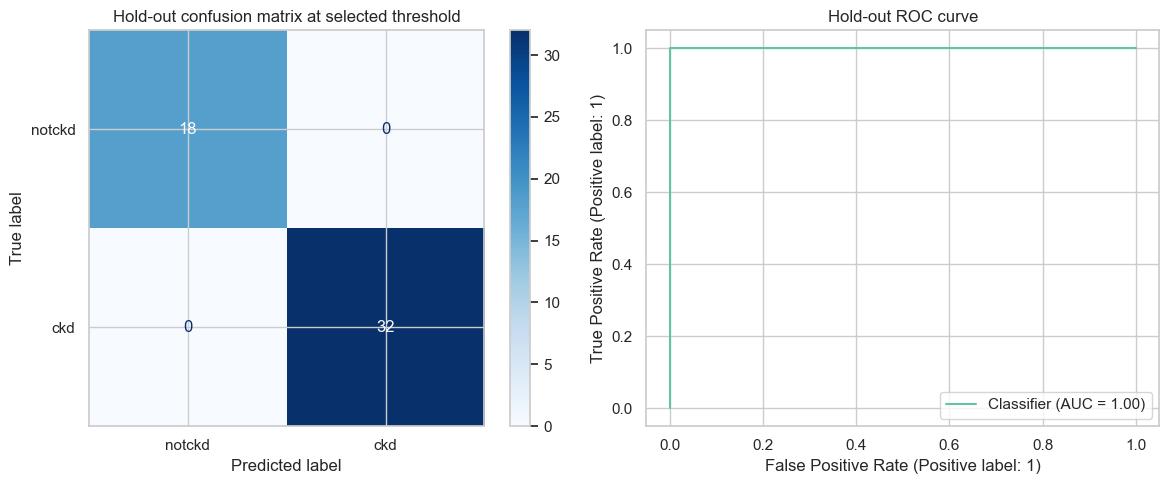

In [229]:
best_model_name = cv_results.iloc[0]["model"]
best_estimator = models[best_model_name]
best_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", best_estimator)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

best_pipe.fit(X_train, y_train)
if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
else:
    y_proba = best_pipe.decision_function(X_test)
    score_range = y_proba.max() - y_proba.min()
    y_proba = (y_proba - y_proba.min()) / score_range if score_range else np.repeat(0.5, len(y_proba))
y_pred_default = (y_proba >= 0.50).astype(int)

precision_curve, recall_curve, threshold_curve = precision_recall_curve(y_test, y_proba)
threshold_rows = []
for threshold, precision_value, recall_value in zip(threshold_curve, precision_curve[:-1], recall_curve[:-1]):
    pred_at_threshold = (y_proba >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_score(y_test, pred_at_threshold),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_at_threshold),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(["recall", "f1"], ascending=False)
candidate_thresholds = threshold_df[threshold_df["recall"] >= 0.90]
if len(candidate_thresholds) > 0:
    selected_threshold = float(candidate_thresholds.sort_values("f1", ascending=False).iloc[0]["threshold"])
else:
    selected_threshold = float(threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"])

y_pred = (y_proba >= selected_threshold).astype(int)

holdout_metrics = pd.DataFrame([{
    "model": best_model_name,
    "selected_threshold": selected_threshold,
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}])

print("Best model by cross-validated F1:", best_model_name)
print("Selected screening threshold:", round(selected_threshold, 3))
print("\nHold-out classification report:")
print(classification_report(y_test, y_pred, target_names=["notckd", "ckd"]))
display(holdout_metrics.style.format({col: "{:.3f}" for col in holdout_metrics.columns if col != "model"}))
print("Top threshold candidates prioritising CKD recall:")
display(threshold_df.head(10).style.format({
    "threshold": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
}))
save_table(holdout_metrics, "holdout_classification_metrics.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["notckd", "ckd"], cmap="Blues", ax=axes[0])
axes[0].set_title("Hold-out confusion matrix at selected threshold")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Hold-out ROC curve")
plt.tight_layout()
plt.show()

,encoded_feature,importance,original_feature
130,num__hemo_mid,0.144933,hemo_mid
131,num__pcv_mid,0.097473,pcv_mid
123,num__al_mid,0.067611,al_mid
122,num__sg_mid,0.063173,sg_mid
13,cat__al_< 0,0.058148,al
101,cat__htn_1,0.056298,htn
132,num__rbcc_mid,0.056250,rbcc_mid
100,cat__htn_0,0.044132,htn
103,cat__dm_1,0.032574,dm
102,cat__dm_0,0.030161,dm


,original_feature,importance
16,hemo_mid,0.144933
17,htn,0.100430
21,pcv_mid,0.097473
3,al_mid,0.067611
2,al,0.065155
31,sg_mid,0.063173
14,dm,0.062735
27,rbcc_mid,0.056250
30,sg,0.034230
15,hemo,0.033461


Saved table: report_tables\original_feature_importance.csv


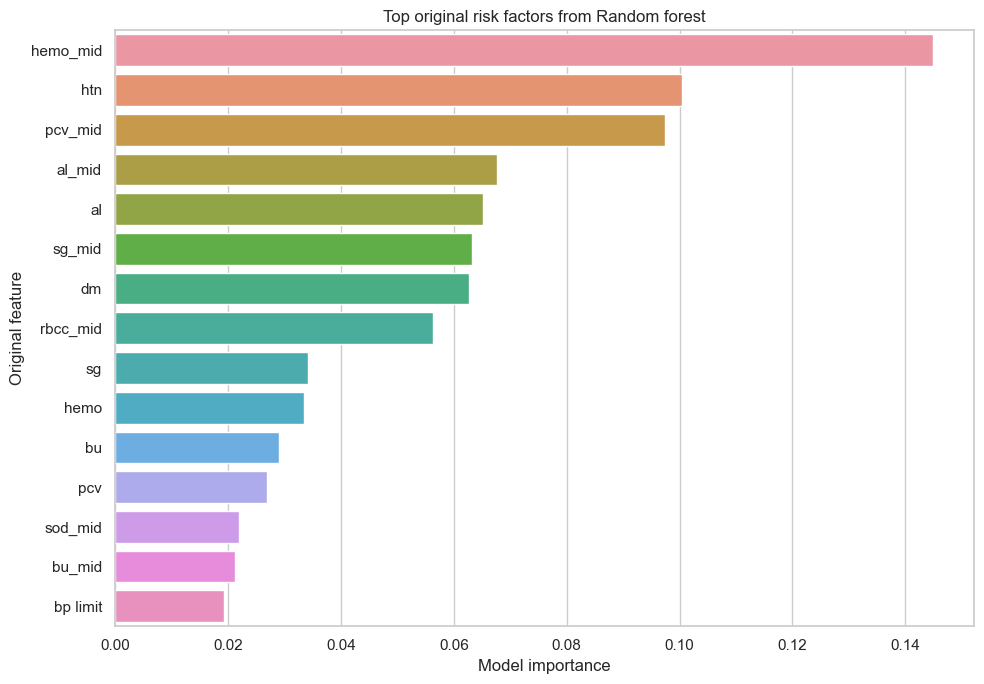

In [230]:
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
trained_model = best_pipe.named_steps["model"]

if hasattr(trained_model, "feature_importances_"):
    importance = trained_model.feature_importances_
elif hasattr(trained_model, "coef_"):
    importance = np.abs(trained_model.coef_).ravel()
else:
    importance = np.zeros(len(feature_names))

importance_df = (
    pd.DataFrame({"encoded_feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
)

def recover_original_feature(encoded_feature):
    if encoded_feature.startswith("num__"):
        return encoded_feature.replace("num__", "")
    if encoded_feature.startswith("cat__"):
        body = encoded_feature.replace("cat__", "")
        for feature in sorted(categorical_features, key=len, reverse=True):
            if body.startswith(feature + "_"):
                return feature
    return encoded_feature


importance_df["original_feature"] = importance_df["encoded_feature"].map(recover_original_feature)
original_importance_df = (
    importance_df.groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(importance_df.head(20))
display(original_importance_df.head(15))
save_table(original_importance_df, "original_feature_importance.csv")

plt.figure(figsize=(10, 7))
sns.barplot(data=original_importance_df.head(15), x="importance", y="original_feature")
plt.title(f"Top original risk factors from {best_model_name}")
plt.xlabel("Model importance")
plt.ylabel("Original feature")
plt.tight_layout()
plt.show()

## 5. Method 2: Regression on GFR

Regression is included because the UCI page identifies this dataset as suitable for regression as well as classification. Here, the target is the midpoint of the `grf` interval. This is an approximate severity estimate rather than a direct laboratory value, so interpretation should be cautious.

,model,MAE,RMSE,R2
0,Random forest regressor,29.02,44.27,0.414
1,Gradient boosting regressor,31.16,49.20,0.277


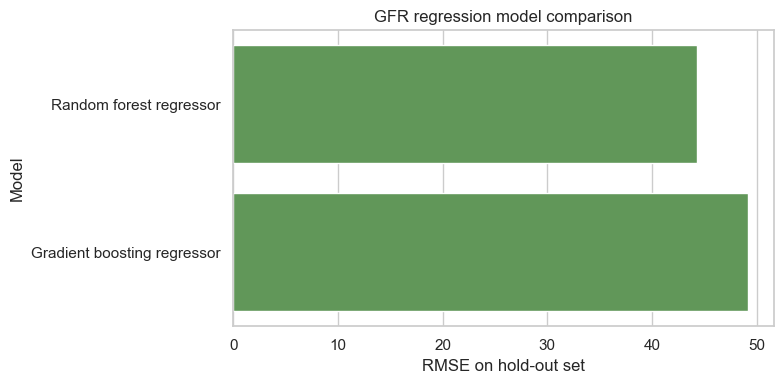

In [231]:
regression_df = model_df.dropna(subset=["grf_mid"]).copy()
regression_leakage = ["class", "ckd_binary", "grf", "grf_mid", "stage", "advanced_stage", "affected"]
X_reg = regression_df.drop(columns=regression_leakage)
y_reg = regression_df["grf_mid"]

reg_preprocess = preprocess
reg_models = {
    "Random forest regressor": RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE),
    "Gradient boosting regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

reg_rows = []
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE)

for name, estimator in reg_models.items():
    pipe = Pipeline(steps=[("preprocess", reg_preprocess), ("model", estimator)])
    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)
    reg_rows.append({
        "model": name,
        "MAE": mean_absolute_error(yr_test, pred),
        "RMSE": math.sqrt(mean_squared_error(yr_test, pred)),
        "R2": r2_score(yr_test, pred),
    })

reg_results = pd.DataFrame(reg_rows).sort_values("RMSE")
display(reg_results.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.3f}"}))

plt.figure(figsize=(8, 4))
sns.barplot(data=reg_results, x="RMSE", y="model", color="#59A14F")
plt.title("GFR regression model comparison")
plt.xlabel("RMSE on hold-out set")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 6. Method 3: Patient Segmentation Using K-Means Clustering

While classification predicts whether a patient has CKD, clustering aims to identify naturally occurring patient groups without using outcome labels during training.

This unsupervised learning approach helps reveal hidden patterns in patient characteristics and supports risk stratification. Identifying patient segments can assist healthcare providers in prioritizing monitoring, screening, and intervention strategies.

K-Means clustering was selected because it is widely used for patient segmentation and can efficiently group patients with similar clinical profiles.

Elbow method WCSS:


,k,wcss
0,1,5009.700000
1,2,4117.862796
2,3,3773.221272
3,4,3526.257119
4,5,3292.689612
5,6,3151.972316
6,7,3057.255488
7,8,2981.176655


Silhouette scores:


,k,silhouette
0,2,0.165540
1,3,0.151523
2,4,0.144069
3,5,0.152321
4,6,0.136435
5,7,0.096285


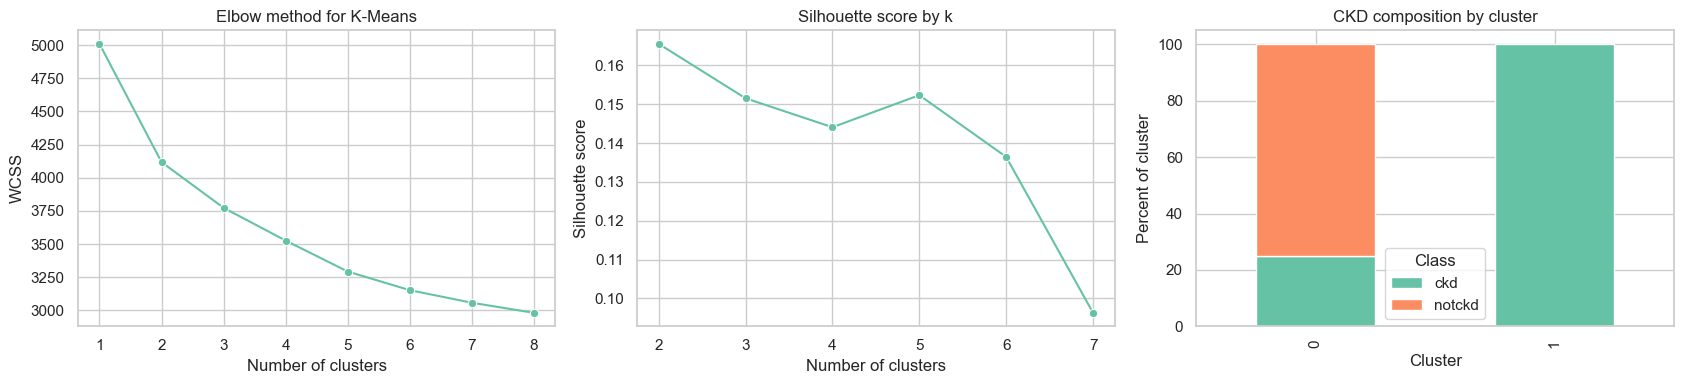

stage,s1,s2,s3,s4,s5
cluster,,,,,
0,53.1,31.2,2.1,11.5,2.1
1,2.9,4.8,27.9,32.7,31.7


Saved table: report_tables\cluster_stage_composition_percent.csv


In [232]:
cluster_features = model_df.drop(columns=["class", "ckd_binary", "grf", "grf_mid", "stage", "advanced_stage", "affected"])
cluster_matrix = preprocess.fit_transform(cluster_features)

wcss = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    km.fit(cluster_matrix)
    wcss.append({"k": k, "wcss": km.inertia_})
wcss_df = pd.DataFrame(wcss)

k_scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(cluster_matrix)
    k_scores.append({"k": k, "silhouette": silhouette_score(cluster_matrix, labels)})

k_scores = pd.DataFrame(k_scores)
print("Elbow method WCSS:")
display(wcss_df)
print("Silhouette scores:")
display(k_scores)

best_k = int(k_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
model_df["cluster"] = kmeans.fit_predict(cluster_matrix)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.lineplot(data=wcss_df, x="k", y="wcss", marker="o", ax=axes[0])
axes[0].set_title("Elbow method for K-Means")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("WCSS")

sns.lineplot(data=k_scores, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")

cluster_ckd = pd.crosstab(model_df["cluster"], model_df["class"], normalize="index") * 100
cluster_ckd.plot(kind="bar", stacked=True, ax=axes[2])
axes[2].set_title("CKD composition by cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Percent of cluster")
axes[2].legend(title="Class")

plt.tight_layout()
plt.show()

cluster_stage = pd.crosstab(model_df["cluster"], model_df["stage"], normalize="index").round(3) * 100
display(cluster_stage)
save_table(cluster_stage.reset_index(), "cluster_stage_composition_percent.csv")

### Cluster Interpretation

Cluster 0 contains a larger proportion of non-CKD and early-stage CKD patients, suggesting a lower-risk population.

Cluster 1 contains a higher concentration of CKD patients and advanced disease stages, indicating a higher-risk group that may require closer monitoring and earlier clinical intervention.

The clustering results demonstrate that patient records naturally separate into clinically meaningful groups even without using CKD labels during model training.

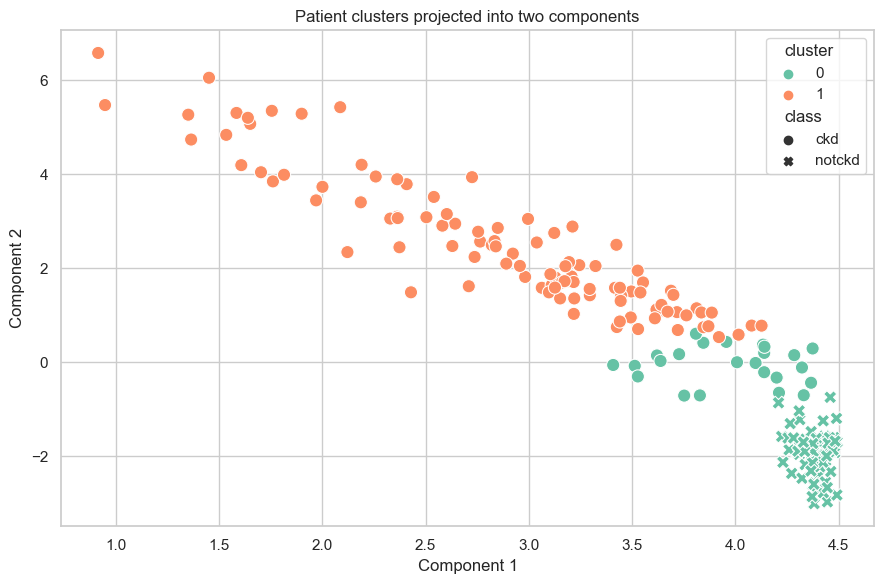

In [233]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(cluster_matrix)

plot_df = pd.DataFrame({
    "component_1": coords[:, 0],
    "component_2": coords[:, 1],
    "cluster": model_df["cluster"].astype(str),
    "class": model_df["class"],
    "stage": model_df["stage"],
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="component_1", y="component_2", hue="cluster", style="class", s=90)
plt.title("Patient clusters projected into two components")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

## 7. Method 4: Association Rule Mining

Association rules provide interpretable risk-factor combinations. Instead of relying on a black-box model only, this section reports combinations of feature values that frequently imply CKD or advanced-stage CKD.

In [234]:
def make_items(row, feature_cols):
    items = []
    for col in feature_cols:
        items.append(f"{col}={row[col]}")
    items.append("class=ckd" if row["ckd_binary"] == 1 else "class=notckd")
    items.append("stage=advanced" if row["advanced_stage"] == 1 else "stage=early")
    return set(items)


rule_feature_cols = [c for c in df.columns if c not in ["class", "stage", "affected", "grf"]]
transactions = model_df.apply(lambda r: make_items(r, rule_feature_cols), axis=1).tolist()
n_transactions = len(transactions)


def support(itemset):
    itemset = set(itemset)
    return sum(itemset.issubset(t) for t in transactions) / n_transactions


def mine_rules(consequent, min_support=0.08, min_confidence=0.65, max_antecedent_size=2):
    all_items = sorted(set().union(*transactions) - {"class=ckd", "class=notckd", "stage=advanced", "stage=early"})
    rows = []
    consequent_set = {consequent}
    consequent_support = support(consequent_set)
    for size in range(1, max_antecedent_size + 1):
        for antecedent in itertools.combinations(all_items, size):
            antecedent_set = set(antecedent)
            ant_support = support(antecedent_set)
            both_support = support(antecedent_set | consequent_set)
            if ant_support == 0:
                continue
            confidence = both_support / ant_support
            lift = confidence / consequent_support if consequent_support else np.nan
            if both_support >= min_support and confidence >= min_confidence:
                rows.append({
                    "antecedent": " AND ".join(antecedent),
                    "consequent": consequent,
                    "support": both_support,
                    "confidence": confidence,
                    "lift": lift,
                })
    columns = ["antecedent", "consequent", "support", "confidence", "lift"]
    if not rows:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(rows, columns=columns).sort_values(["lift", "confidence", "support"], ascending=False)


ckd_rules = mine_rules("class=ckd", min_support=0.08, min_confidence=0.70, max_antecedent_size=2)
advanced_rules = mine_rules("stage=advanced", min_support=0.08, min_confidence=0.60, max_antecedent_size=2)

print("Top CKD rules")
display(ckd_rules.head(15).style.format({"support": "{:.2f}", "confidence": "{:.2f}", "lift": "{:.2f}"}))
save_table(ckd_rules, "association_rules_ckd.csv")

print("Top advanced-stage rules")
display(advanced_rules.head(15).style.format({"support": "{:.2f}", "confidence": "{:.2f}", "lift": "{:.2f}"}))

Top CKD rules


,antecedent,consequent,support,confidence,lift
15,htn=1,class=ckd,0.39,1.00,1.56
345,htn=1 AND pot=< 7.31,class=ckd,0.38,1.00,1.56
170,ba=0 AND htn=1,class=ckd,0.36,1.00,1.56
11,dm=1,class=ckd,0.35,1.00,1.56
300,dm=1 AND pot=< 7.31,class=ckd,0.34,1.00,1.56
166,ba=0 AND dm=1,class=ckd,0.33,1.00,1.56
340,htn=1 AND pcc=0,class=ckd,0.30,1.00,1.56
346,htn=1 AND rbc=0,class=ckd,0.30,1.00,1.56
266,cad=0 AND htn=1,class=ckd,0.29,1.00,1.56
301,dm=1 AND rbc=0,class=ckd,0.28,1.00,1.56


Saved table: report_tables\association_rules_ckd.csv
Top advanced-stage rules


,antecedent,consequent,support,confidence,lift
12,sc=3.65 - 6.8,stage=advanced,0.11,1.00,2.50
135,pot=< 7.31 AND sc=3.65 - 6.8,stage=advanced,0.10,1.00,2.50
57,ba=0 AND sc=3.65 - 6.8,stage=advanced,0.10,1.00,2.50
114,htn=1 AND sc=3.65 - 6.8,stage=advanced,0.10,1.00,2.50
129,pcc=0 AND sc=3.65 - 6.8,stage=advanced,0.09,1.00,2.50
138,sc=3.65 - 6.8 AND su=< 0,stage=advanced,0.09,1.00,2.50
92,cad=0 AND sc=3.65 - 6.8,stage=advanced,0.08,1.00,2.50
136,rbc=0 AND sc=3.65 - 6.8,stage=advanced,0.08,1.00,2.50
29,ane=1 AND htn=1,stage=advanced,0.10,0.91,2.28
28,ane=1 AND dm=1,stage=advanced,0.09,0.89,2.24


## 8. Healthcare and Business Intelligence

The model can be translated into a simple risk-prioritisation workflow:

- **High probability of CKD:** prioritise confirmatory kidney-function testing and nephrology review.
- **Moderate probability:** repeat laboratory screening, monitor blood pressure and diabetes indicators, and schedule follow-up.
- **Low probability:** routine monitoring and preventive education.

For healthcare operations, this supports:

- Better allocation of screening resources.
- Earlier referral for high-risk patients.
- Population-level monitoring of risk-factor burden.
- Clearer communication of model-driven risk factors to clinicians and administrators.

,risk_band,patients,observed_ckd_rate,mean_predicted_probability
0,Low,18,0.0%,6.0%
1,Moderate,2,100.0%,61.3%
2,High,30,100.0%,96.4%


Saved table: report_tables\risk_band_summary.csv


,risk_band,suggested_action,operational_value
0,Low,Routine preventive education and scheduled scr...,Avoids unnecessary urgent workload
1,Moderate,"Repeat kidney-function test, monitor blood pre...",Supports follow-up planning
2,High,Prioritise confirmatory testing and nephrology...,Targets limited specialist resources to highes...


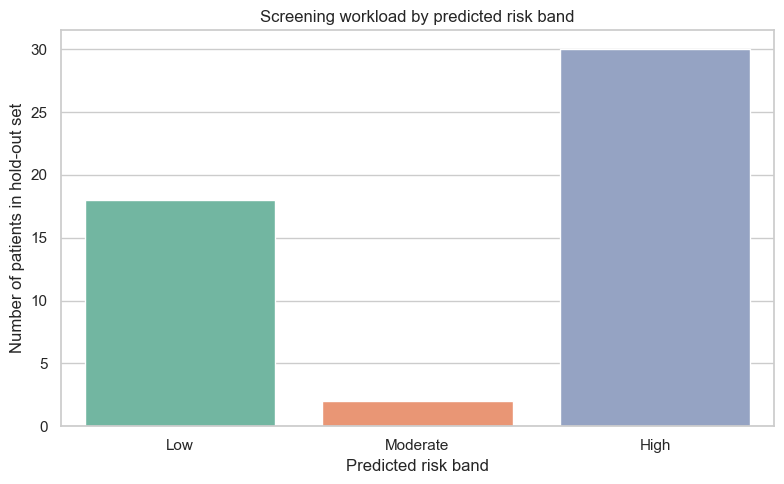

In [235]:
risk_demo = X_test.copy()
risk_demo["actual_ckd"] = y_test.values
risk_demo["predicted_ckd_probability"] = y_proba
risk_demo["risk_band"] = pd.cut(
    risk_demo["predicted_ckd_probability"],
    bins=[-0.01, 0.35, 0.70, 1.01],
    labels=["Low", "Moderate", "High"],
)

band_summary = (
    risk_demo.groupby("risk_band", observed=False)
    .agg(
        patients=("actual_ckd", "size"),
        observed_ckd_rate=("actual_ckd", "mean"),
        mean_predicted_probability=("predicted_ckd_probability", "mean"),
    )
    .reset_index()
)

display(band_summary.style.format({
    "observed_ckd_rate": "{:.1%}",
    "mean_predicted_probability": "{:.1%}",
}))
save_table(band_summary, "risk_band_summary.csv")

clinical_action_table = pd.DataFrame({
    "risk_band": ["Low", "Moderate", "High"],
    "suggested_action": [
        "Routine preventive education and scheduled screening",
        "Repeat kidney-function test, monitor blood pressure and diabetes indicators",
        "Prioritise confirmatory testing and nephrology referral review",
    ],
    "operational_value": [
        "Avoids unnecessary urgent workload",
        "Supports follow-up planning",
        "Targets limited specialist resources to highest-risk patients",
    ],
})
display(clinical_action_table)

plt.figure(figsize=(8, 5))
sns.barplot(data=band_summary, x="risk_band", y="patients")
plt.title("Screening workload by predicted risk band")
plt.xlabel("Predicted risk band")
plt.ylabel("Number of patients in hold-out set")
plt.tight_layout()
plt.show()

## 9. Discussion

**Expected interpretation points for the report**

- Compare all classification models against the dummy baseline. The selected model should justify both predictive performance and clinical usefulness.
- Prioritise recall/sensitivity for CKD screening because missing a true CKD patient is clinically costly.
- Use precision to discuss false positives and operational workload.
- Interpret important features and association rules as risk signals, not causal proof.
- Discuss clustering as patient segmentation rather than diagnosis.
- Acknowledge dataset limitations: small sample size, interval-coded variables, single-country clinical source, and potential generalisability concerns.

**Ethics and safety**

This notebook supports decision-making but should not make autonomous medical decisions. Any deployment would require external validation, bias testing, clinical governance, and integration with clinician review.

In [236]:
summary_table = pd.DataFrame({
    "Rubric area": [
        "Problem definition",
        "Data understanding and preprocessing",
        "Methodology",
        "Results and evaluation",
        "Business intelligence",
        "Presentation readiness",
    ],
    "Notebook evidence": [
        "Clinical CKD screening objective and decision-support framing",
        "Metadata-row removal, encoding cleanup, leakage control, missing-value check, EDA",
        "Classification, regression, clustering, and association rules",
        "Cross-validation, hold-out test, confusion matrix, ROC, regression metrics, silhouette score",
        "Risk bands, clinical actions, resource-prioritisation interpretation",
        "Report-ready figures, concise tables, discussion and limitations",
    ],
})
display(summary_table)
print("Report tables folder:", TABLE_DIR.resolve())

,Rubric area,Notebook evidence
0,Problem definition,Clinical CKD screening objective and decision-...
1,Data understanding and preprocessing,"Metadata-row removal, encoding cleanup, leakag..."
2,Methodology,"Classification, regression, clustering, and as..."
3,Results and evaluation,"Cross-validation, hold-out test, confusion mat..."
4,Business intelligence,"Risk bands, clinical actions, resource-priorit..."
5,Presentation readiness,"Report-ready figures, concise tables, discussi..."


Report tables folder: C:\Users\Ke Xin\Desktop\Master\KQC7016 Data Analytics\Assignment 2\report_tables


In [237]:
table_manifest = sorted(str(path) for path in TABLE_DIR.glob("*.csv"))

print("\nTables created for report:")
for path in table_manifest:
    print("-", path)


Tables created for report:
- report_tables\association_rules_ckd.csv
- report_tables\classification_cross_validation_results.csv
- report_tables\cluster_stage_composition_percent.csv
- report_tables\holdout_classification_metrics.csv
- report_tables\original_feature_importance.csv
- report_tables\risk_band_summary.csv
